# Final Model Evaluation

This notebook consolidates our best models and evaluates them beyond just accuracy.

Starting with our best neural network:

In [2]:
import pandas as pd

data = pd.read_csv('/workspaces/group-project-bas-team/data/cleaned_data_with_parent.csv')
data_unencoded = pd.read_csv('/workspaces/group-project-bas-team/data/data_unencoded.csv')

data[['Survey ResponseID', 'Order Date']] = data_unencoded[['Survey ResponseID', 'Order Date']]

data['Order Date'] = pd.to_datetime(data['Order Date'])
data = data.sort_values(by=['Survey ResponseID', 'Order Date'])
data['Purchase_Order'] = data.groupby('Survey ResponseID')['Order Date'].rank(method='first').astype(int)

data['Days_Since_Last_Purchase'] = data.groupby('Survey ResponseID')['Order Date'].diff().dt.days.fillna(0)

data = data.drop(columns=['Order Date'])

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
data['Survey ResponseID'] = encoder.fit_transform(data['Survey ResponseID'])

from sklearn.preprocessing import StandardScaler

train = data[data['order_year']<=2021]
test = data[data['order_year']>2021]

train_cats = set(train['Category'].unique())
test_cats = set(test['Category'].unique())
unseen = test_cats - train_cats
if len(unseen) > 0:
    test = test[~test['Category'].isin(unseen)]


data_limited_train = train.drop(['Title', 'ASIN/ISBN (Product Code)', 'Category'], axis=1)
data_limited_test = test.drop(['Title', 'ASIN/ISBN (Product Code)', 'Category'], axis=1)

X_train = data_limited_train.drop('parent_category', axis=1)
y_train = data_limited_train['parent_category']
X_train_scaled = StandardScaler().fit_transform(X_train)

X_test = data_limited_test.drop('parent_category', axis=1)
y_test = data_limited_test['parent_category']
X_test_scaled = StandardScaler().fit_transform(X_test)

X_train = X_train.drop(X_train.filter(regex='^Shipping Address').columns, axis=1)
X_test = X_test.drop(X_test.filter(regex='^Shipping Address').columns, axis=1)

X_train = X_train.drop(columns = ['diabetes_No', 'wheelchair_No', 'marijuana_No', 'sexual-orientation_heterosexual (straight)', 
                                  'gender_Female', 'alcohol_No'])
X_test = X_test.drop(columns = ['diabetes_No', 'wheelchair_No', 'marijuana_No', 'sexual-orientation_heterosexual (straight)', 
                                  'gender_Female', 'alcohol_No'])

X_train_scaled = StandardScaler().fit_transform(X_train)
X_test_scaled = StandardScaler().fit_transform(X_test) 

/tmp/ipykernel_19143/600300412.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[['Survey ResponseID', 'Order Date']] = data_unencoded[['Survey ResponseID', 'Order Date']]
/tmp/ipykernel_19143/600300412.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['Purchase_Order'] = data.groupby('Survey ResponseID')['Order Date'].rank(method='first').astype(int)
/tmp/ipykernel_19143/600300412.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has

In [ ]:
import tensorflow as tf

tf.keras.backend.clear_session()
tf.random.set_seed(42)

model = tf.keras.Sequential()

model.add(tf.keras.layers.InputLayer(input_shape=(102, )))

model.add(tf.keras.layers.Dense(300, activation="relu")) 

model.add(tf.keras.layers.Dense(100, activation="relu"))

model.add(tf.keras.layers.Dense(15, activation="softmax")) 

/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [14]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="sgd",
              metrics=["accuracy", tf.keras.metrics.F1Score(average="weighted")])

In [15]:
history = model.fit(X_train_scaled, y_train, epochs=30, shuffle=False, verbose=2)

Epoch 1/30


W0000 00:00:1777945211.638100   19143 cpu_allocator_impl.cc:82] Allocation of 46371240 exceeds 10% of free system memory.


3552/3552 - 7s - 2ms/step - accuracy: 0.2452 - f1_score: 0.1295 - loss: 2.3716
Epoch 2/30
3552/3552 - 10s - 3ms/step - accuracy: 0.2574 - f1_score: 0.1293 - loss: 2.3071
Epoch 3/30
3552/3552 - 5s - 1ms/step - accuracy: 0.2644 - f1_score: 0.1294 - loss: 2.2824
Epoch 4/30
3552/3552 - 6s - 2ms/step - accuracy: 0.2698 - f1_score: 0.1294 - loss: 2.2644
Epoch 5/30
3552/3552 - 6s - 2ms/step - accuracy: 0.2743 - f1_score: 0.1295 - loss: 2.2476
Epoch 6/30
3552/3552 - 6s - 2ms/step - accuracy: 0.2788 - f1_score: 0.1295 - loss: 2.2315
Epoch 7/30
3552/3552 - 7s - 2ms/step - accuracy: 0.2830 - f1_score: 0.1296 - loss: 2.2160
Epoch 8/30
3552/3552 - 9s - 2ms/step - accuracy: 0.2877 - f1_score: 0.1296 - loss: 2.2020
Epoch 9/30
3552/3552 - 6s - 2ms/step - accuracy: 0.2923 - f1_score: 0.1297 - loss: 2.1892
Epoch 10/30
3552/3552 - 11s - 3ms/step - accuracy: 0.2954 - f1_score: 0.1297 - loss: 2.1780
Epoch 11/30
3552/3552 - 13s - 4ms/step - accuracy: 0.2988 - f1_score: 0.1297 - loss: 2.1683
Epoch 12/30
3552

In [16]:
test_loss, test_acc, test_f1 = model.evaluate(X_test_scaled, y_test, verbose=2)
print('\nTest Accuracy:', test_acc)
print('\nTest F1-score:', test_f1)

1355/1355 - 3s - 2ms/step - accuracy: 0.2733 - f1_score: 0.1303 - loss: 2.2802

Test Accuracy: 0.27328118681907654

Test F1-score: 0.1302928328514099


1355/1355 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


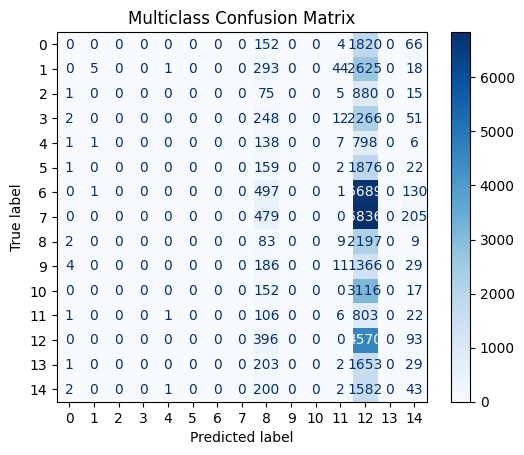

In [17]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)

y_pred = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1) if len(y_test.shape) > 1 else y_test

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap=plt.cm.Blues)
plt.title("Multiclass Confusion Matrix")
plt.show()

### Neural network final metrics:

Accuracy: 27.33% \
F1: 13.0%

The neural network seems to be heavily over predicting two classes, leading to a higher accuracy but low F1 score.